1. Carga de Datos:

Importar las librerías necesarias (pandas, json, matplotlib.pyplot, seaborn, etc.).
Cargar el archivo corpus.json que guarda los títulos y contenidos de los artículos. Convertirlo en un DataFrame.

In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

try:
    with open('corpus.json', 'r', encoding='utf-8') as f:
        corpus = json.load(f)
    df_corpus = pd.DataFrame(corpus)
    print("Corpus cargado correctamente.")
    print(df_corpus.head())
except FileNotFoundError:
    print("Error: No se encontró el archivo corpus.json. Asegúrate de haber ejecutado el script principal.")
except json.JSONDecodeError:
    print("Error: Problema al decodificar el archivo corpus.json.")

Corpus cargado correctamente.
                                              titulo  \
0  AI Offers Digital Immortality for Deceased Lov...   
1  AI Offers Digital Immortality for Deceased Lov...   
2  This Impossible New Color Is So Rare That Only...   
3  This Impossible New Color Is So Rare That Only...   
4                       Can There Be Sound in Space?   

                                           contenido  polaridad  subjetividad  \
0  AI chatbots called “griefbots” or “deadbots” o...   0.099207      0.413700   
1  AI chatbots called “griefbots” or “deadbots” o...        NaN           NaN   
2  This Impossible New Color Is So Rare That Only...   0.115966      0.447681   
3  This Impossible New Color Is So Rare That Only...        NaN           NaN   
4  5min read Can There Be Sound in Space? It seem...   0.083652      0.437987   

                                           entidades  
0                                               None  
1  [[AI, ORG], [ByRachel Feltman, PE

2. Análisis Básico del Corpus:

Mostrar el número de artículos extraídos.
Ver la longitud promedio de los contenidos de los artículos.
Explorar la distribución de la longitud de los títulos y contenidos (histogramas).


Número de artículos: 10
Longitud promedio del contenido: 8158.00 caracteres.


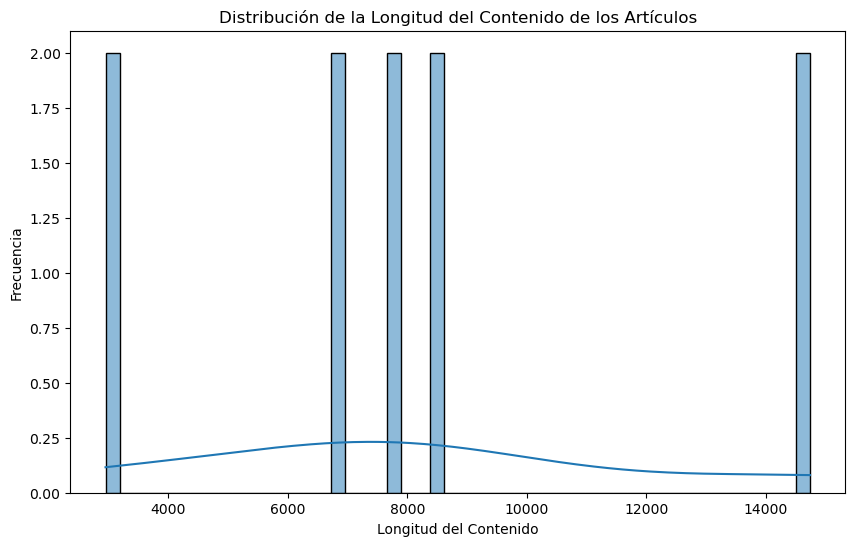

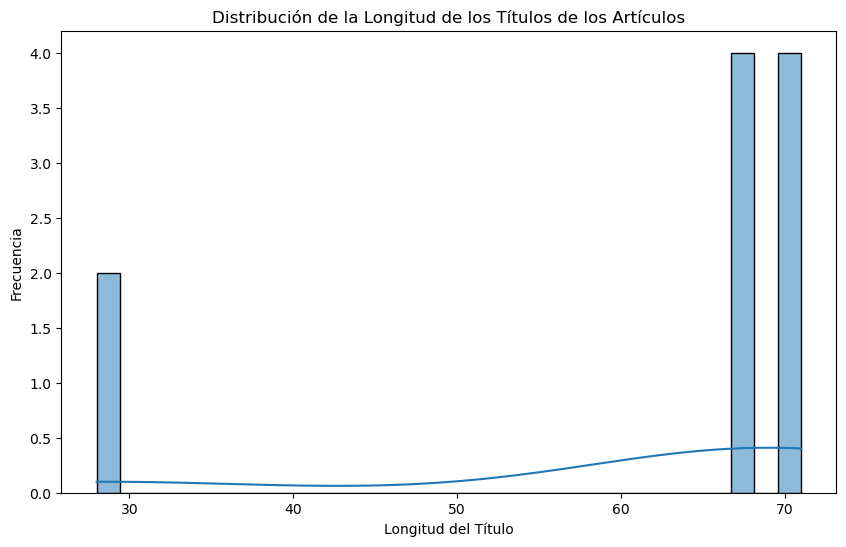

In [3]:
if 'contenido' in df_corpus:
    df_corpus['longitud_contenido'] = df_corpus['contenido'].apply(len)
    print(f"\nNúmero de artículos: {len(df_corpus)}")
    print(f"Longitud promedio del contenido: {df_corpus['longitud_contenido'].mean():.2f} caracteres.")

    plt.figure(figsize=(10, 6))
    sns.histplot(df_corpus['longitud_contenido'], bins=50, kde=True)
    plt.title('Distribución de la Longitud del Contenido de los Artículos')
    plt.xlabel('Longitud del Contenido')
    plt.ylabel('Frecuencia')
    plt.show()

if 'titulo' in df_corpus:
    df_corpus['longitud_titulo'] = df_corpus['titulo'].apply(len)
    plt.figure(figsize=(10, 6))
    sns.histplot(df_corpus['longitud_titulo'], bins=30, kde=True)
    plt.title('Distribución de la Longitud de los Títulos de los Artículos')
    plt.xlabel('Longitud del Título')
    plt.ylabel('Frecuencia')
    plt.show()

3. Análisis de Frecuencia de Palabras (Inicial):

Importar las funciones de preprocesamiento (limpiar_texto, procesar_texto) desde src.preprocessor.
Aplicar el preprocesamiento a una muestra de los contenidos.
Calcular la frecuencia de las palabras usando collections.Counter.
Mostrar las palabras más comunes.

In [4]:
from collections import Counter
from src.preprocessor import limpiar_texto, procesar_texto

if 'contenido' in df_corpus:
    muestra_contenido = df_corpus['contenido'].sample(min(10, len(df_corpus))).tolist()
    todos_los_tokens = []
    for texto in muestra_contenido:
        texto_limpio = limpiar_texto(texto)
        tokens = procesar_texto(texto_limpio)
        todos_los_tokens.extend(tokens)

    frecuencia_inicial = Counter(todos_los_tokens)
    print("\nPalabras más frecuentes:")
    print(frecuencia_inicial.most_common(20))


Palabras más frecuentes:
[('number', 68), ('prime', 58), ('space', 48), ('card', 44), ('idea', 42), ('technology', 42), ('scientific', 40), ('american', 38), ('s', 36), ('like', 36), ('magic', 36), ('new', 34), ('color', 32), ('think', 32), ('use', 32), ('game', 32), ('world', 30), ('particle', 30), ('digital', 30), ('people', 28)]


4. Pruebas de Visualización:

Importar la función crear_nube_palabras_redonda desde src.analyzer.
Generar nubes de palabras con diferentes parámetros (max_words, colormap) para una muestra del corpus procesado.


Nube de palabras (muestra):


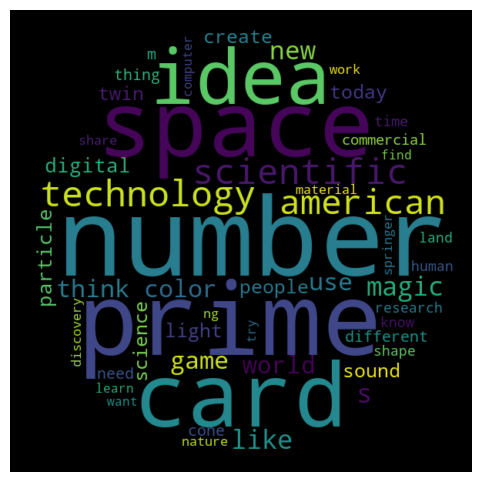

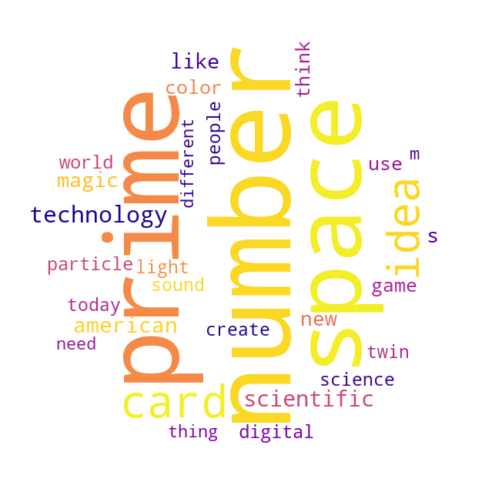

In [6]:
from src.analyzer import crear_nube_palabras_redonda

if frecuencia_filtrada:
    print("\nNube de palabras (muestra):")
    crear_nube_palabras_redonda(dict(frecuencia_filtrada.most_common(50)), num_palabras=50, colormap='viridis')
    crear_nube_palabras_redonda(dict(frecuencia_filtrada.most_common(30)), num_palabras=30, background_color='white', colormap='plasma')

6. Experimentación con Análisis Avanzado (si los implementas):

Si has implementado análisis de sentimiento o NER en analyzer.py, podrías probarlos en una muestra de los datos y visualizar los resultados (por ejemplo, la distribución de la polaridad del sentimiento).
Para el modelado de temas, podrías preprocesar todo el corpus y probar diferentes números de temas y visualizar las palabras clave por tema.

7. Guardado de Resultados Exploratorios (Opcional):

Si encuentras resultados interesantes durante tu exploración, podrías guardar visualizaciones o estadísticas en archivos para referencia futura.